In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path

In [4]:
def get_assets(
    companies_list = [], 
    start_date: str = "2024-07-01",
    end_date: str = "2025-06-30",
    sample_size: int=10, 
    companies_file: Path = Path(
        r"C:\Users\patri\OneDrive\Projects\pyton\portfolio_optimzation\data\S_n_P_500.csv")    
) -> tuple[pd.DataFrame, pd.DataFrame]:

    import yfinance as yf

    tickers: List[str] = companies_list
    if len(tickers) < 1: 
        companies = pd.read_csv(companies_file)
        tickers: List[str] = companies.iloc[:, 0].sample(
            n=sample_size, replace=False
        ).tolist()
 

    # --- Download price data -------------------------------------------------
    data = yf.download(
        tickers=tickers,
        start=start_date,
        end=end_date,
        interval="1d",
        group_by="ticker",
        auto_adjust=False,
        progress=False
    )

    trading_days = 252
    rows = []

    # --- Build Close Price DataFrame for all tickers -------------------------
    close_df = pd.DataFrame()

    for ticker in tickers:
        try:
            close_df[ticker] = data[ticker]["Close"]
        except Exception:
            close_df[ticker] = None

    close_df = close_df.dropna()

    # --- Compute Daily Returns for ALL assets --------------------------------
    daily_returns = close_df.pct_change().dropna()

    # --- Compute summary stats per ticker ------------------------------------
    for ticker in tickers:
        try:
            close_prices = close_df[ticker].dropna()
            last_close = round(close_prices.iloc[-1], 2)

            returns = daily_returns[ticker]
            n_days = len(returns)

            # CAGR
            annual_return = round(
                ((close_prices.iloc[-1] / close_prices.iloc[0]) 
                 ** (trading_days / n_days) - 1) * 100, 6
            )

            # Annualized volatility
            annual_volatility = round(
                returns.std() * (trading_days ** 0.5) * 100, 6
            )

            rows.append([ticker, last_close, annual_return, annual_volatility])

        except Exception:
            rows.append([ticker, None, None, None])

    summary_df = pd.DataFrame(
        rows,
        columns=["Ticker", "Last Close", "CAGR (%)", "Volatility (%)"]
    )

    return summary_df, daily_returns

In [ ]:
summary_df, daily_returns = get_assets(["AAPL", "MSFT", "NVDA"])

In [13]:
summary_df, daily_returns = get_assets()

In [15]:
summary_df.head(10)

,Ticker,Last Close,CAGR (%),Volatility (%)
0,MTCH,30.85,5.231702,40.718202
1,HUM,241.88,-35.690106,44.035995
2,O,57.03,9.069210,18.289095
3,WM,228.26,9.179603,19.923442
4,ADBE,385.83,-31.515780,34.213157
5,ODFL,163.68,-8.534762,39.346465
6,OKE,81.25,-0.584385,31.756465
7,ULTA,458.27,19.552266,40.779398
8,ZBH,91.46,-13.889041,26.562286
9,PCAR,94.89,-6.930594,30.562032


In [16]:
daily_returns.head()

,MTCH,HUM,O,WM,ADBE,ODFL,OKE,ULTA,ZBH,PCAR
Date,,,,,,,,,,
2024-07-02,0.003749,0.003561,0.001337,0.000525,0.013750,0.019418,0.007465,0.022398,0.002926,-0.009132
2024-07-03,0.002377,-0.031935,0.000381,0.003485,0.004298,-0.001647,0.005709,-0.008524,0.002917,0.010802
2024-07-05,-0.003388,0.016453,0.012202,0.000618,0.014365,0.004949,-0.006643,0.000847,0.013417,-0.017451
2024-07-08,0.026513,0.004365,0.001319,0.001379,-0.005084,-0.009356,-0.003040,0.014923,-0.014999,0.010577
2024-07-09,0.024503,0.007910,-0.007524,-0.002849,-0.016302,-0.014636,0.005122,0.000480,-0.005922,0.000592


In [18]:
corr = daily_returns.corr()

In [19]:
cov = daily_returns.cov()

In [ ]:

assets = summary_df['Ticker'].to_list()

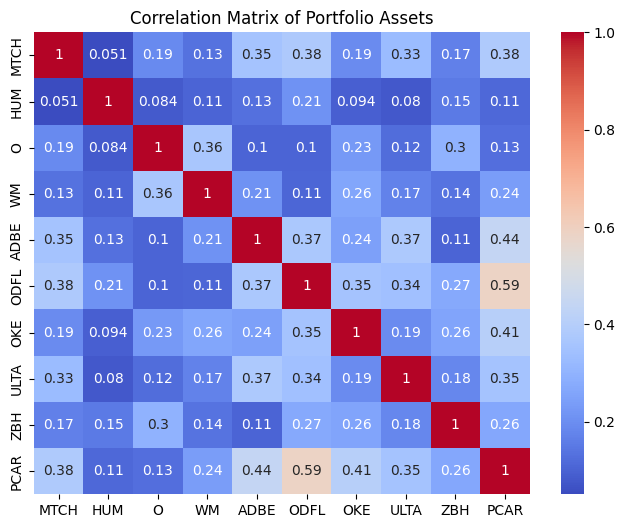

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', xticklabels=assets, yticklabels=assets)
plt.title("Correlation Matrix of Portfolio Assets")
plt.show()